In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/Telco_Customer_Churn.csv")

In [7]:
#Keep customerID around separately (not in df used for training)
#if you ever need to map predictions back to specific customers later
#— e.g.
customerids = df['customerID']
df = df.drop(columns=['customerID'])

In [8]:
#Fix TotalCharges — it's currently a string. Convert it and handle the resulting NaNs (usually ~11 rows where tenure=0):
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)  # or drop those rows

<Axes: xlabel='Churn', ylabel='count'>

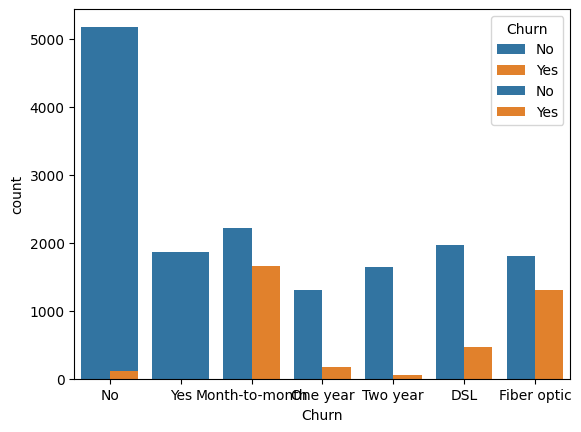

In [9]:
#1. countplot — categorical vs categorical
#Use when you want to see counts/frequency of a category, optionally split by another category. Great for checking class balance and how a feature relates to your target (Churn).

sns.countplot(x='Churn', data=df)  # class balance - is it imbalanced?
sns.countplot(x='Contract', hue='Churn', data=df)  # does contract type affect churn?
sns.countplot(x='InternetService', hue='Churn', data=df)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

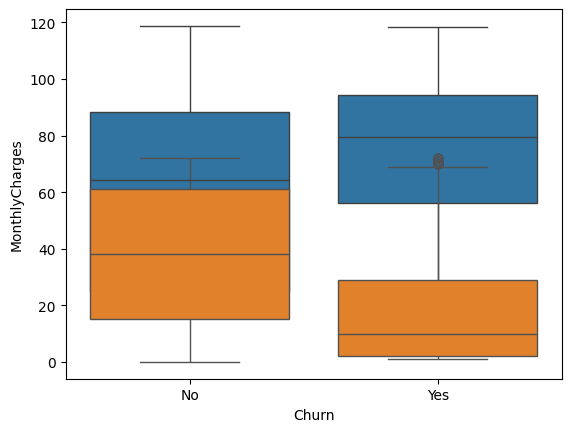

In [10]:
#boxplot — numerical vs categorical
#Use when comparing the distribution (median, spread, outliers) of a numeric column across categories. Great for seeing if a numeric feature differs meaningfully between churned/non-churned customers.


sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
sns.boxplot(x='Churn', y='tenure', data=df)

<Axes: xlabel='tenure', ylabel='Count'>

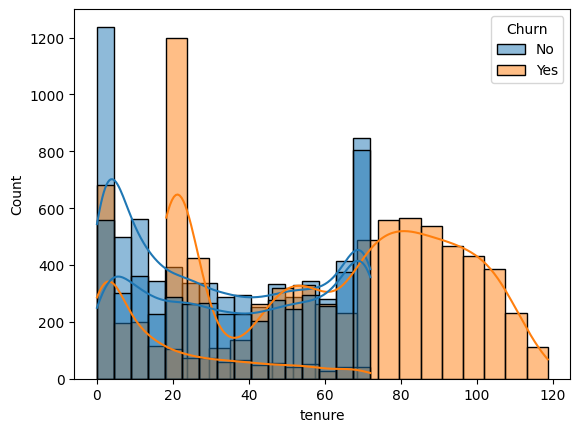

In [11]:
#histplot / df.hist() — numerical distribution
#Use to see the shape of a single numeric variable (skewed? normal? bimodal?).
#Important because skewed features sometimes benefit from transformation (log, etc.).

sns.histplot(df['tenure'], kde=True)
sns.histplot(df['MonthlyCharges'], kde=True)
sns.histplot(data=df, x='tenure', hue='Churn', kde=True)  # split by target#

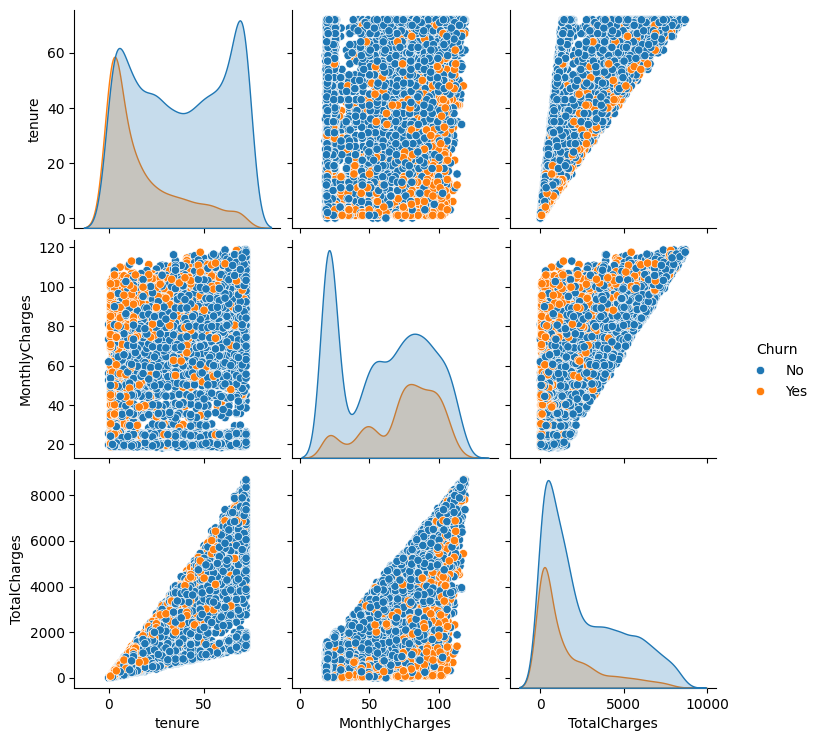

In [12]:
#pairplot — numerical vs numerical, all at once
#Use for a quick overview of relationships between multiple numeric columns simultaneously. Careful: expensive on datasets with many numeric columns or many rows.

sns.pairplot(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']], hue='Churn')

<Axes: >

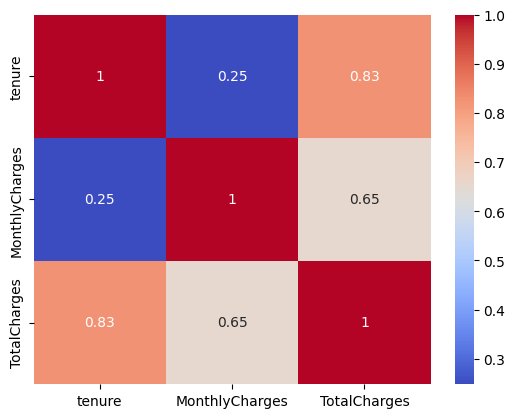

In [13]:
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges']].corr(), annot=True, cmap='coolwarm')

In [14]:
from sklearn.preprocessing import LabelEncoder

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# One-hot encode remaining categorical columns
df = pd.get_dummies(df, drop_first=True)

Y = df["Churn"]
X = df.drop("Churn", axis=1)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

# Scale features (fit on train only, apply to both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_scaled, Y_train)

print("Train accuracy:", model_lr.score(X_train_scaled, Y_train))
print("Test accuracy:", model_lr.score(X_test_scaled, Y_test))

y_test_pred = model_lr.predict(X_test_scaled)
print(confusion_matrix(Y_test, y_test_pred))
print(classification_report(Y_test, y_test_pred))

Train accuracy: 0.8042596348884381
Test accuracy: 0.8092759110269758
[[1394  158]
 [ 245  316]]
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1552
           1       0.67      0.56      0.61       561

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113



In [22]:
!pip install gradio -q

import gradio as gr
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

# --- Rebuild pipeline from raw data ---
df_raw = pd.read_csv("Telco_Customer_Churn.csv")
df_raw = df_raw.drop(columns=["customerID"])
df_raw["TotalCharges"] = pd.to_numeric(df_raw["TotalCharges"], errors="coerce").fillna(0)

binary_cols = ["gender","Partner","Dependents","PhoneService","PaperlessBilling","Churn"]
le_dict = {}
for col in binary_cols:
    le = LabelEncoder()
    df_raw[col] = le.fit_transform(df_raw[col])
    le_dict[col] = le

multi_cols = ["MultipleLines","InternetService","OnlineSecurity","OnlineBackup",
              "DeviceProtection","TechSupport","StreamingTV","StreamingMovies",
              "Contract","PaymentMethod"]
df_encoded = pd.get_dummies(df_raw, columns=multi_cols, drop_first=True)

X = df_encoded.drop("Churn", axis=1)
Y = df_encoded["Churn"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, Y)

feature_columns = X.columns.tolist()

# --- Prediction function used by Gradio ---
# def predict_churn(gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService,
#                    MultipleLines, InternetService, OnlineSecurity, OnlineBackup,
#                    DeviceProtection, TechSupport, StreamingTV, StreamingMovies,
#                    Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges):

#     input_df = pd.DataFrame([{
#         "gender": gender, "SeniorCitizen": SeniorCitizen, "Partner": Partner,
#         "Dependents": Dependents, "tenure": tenure, "PhoneService": PhoneService,
#         "MultipleLines": MultipleLines, "InternetService": InternetService,
#         "OnlineSecurity": OnlineSecurity, "OnlineBackup": OnlineBackup,
#         "DeviceProtection": DeviceProtection, "TechSupport": TechSupport,
#         "StreamingTV": StreamingTV, "StreamingMovies": StreamingMovies,
#         "Contract": Contract, "PaperlessBilling": PaperlessBilling,
#         "PaymentMethod": PaymentMethod, "MonthlyCharges": MonthlyCharges,
#         "TotalCharges": TotalCharges
#     }])

#     for col in ["gender","Partner","Dependents","PhoneService","PaperlessBilling"]:
#         input_df[col] = le_dict[col].transform(input_df[col])

#     input_df = pd.get_dummies(input_df, columns=multi_cols, drop_first=True)
#     input_df = input_df.reindex(columns=feature_columns, fill_value=0)

#     input_scaled = scaler.transform(input_df)
#     pred = model.predict(input_scaled)[0]
#     prob = model.predict_proba(input_scaled)[0][1]

#     result = "Yes (Will Churn)" if pred == 1 else "No (Will Stay)"
#     return f"{result} — churn probability: {prob:.2%}"
def predict_churn(gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService,
                   MultipleLines, InternetService, OnlineSecurity, OnlineBackup,
                   DeviceProtection, TechSupport, StreamingTV, StreamingMovies,
                   Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges):

    raw_input = {
        "gender": gender, "Partner": Partner, "Dependents": Dependents,
        "PhoneService": PhoneService, "PaperlessBilling": PaperlessBilling,
        "SeniorCitizen": SeniorCitizen, "tenure": tenure,
        "MonthlyCharges": MonthlyCharges, "TotalCharges": TotalCharges,
        "MultipleLines": MultipleLines, "InternetService": InternetService,
        "OnlineSecurity": OnlineSecurity, "OnlineBackup": OnlineBackup,
        "DeviceProtection": DeviceProtection, "TechSupport": TechSupport,
        "StreamingTV": StreamingTV, "StreamingMovies": StreamingMovies,
        "Contract": Contract, "PaymentMethod": PaymentMethod,
    }

    encoded_input = {}
    # binary columns -> use the same LabelEncoders from training
    for col in ["gender","Partner","Dependents","PhoneService","PaperlessBilling"]:
        encoded_input[col] = le_dict[col].transform([raw_input[col]])[0]

    # numeric columns -> pass through as-is
    for col in ["SeniorCitizen","tenure","MonthlyCharges","TotalCharges"]:
        encoded_input[col] = raw_input[col]

    # multi-category columns -> manually set the matching one-hot column to 1
    for col in multi_cols:
        val = raw_input[col]
        dummy_col = f"{col}_{val}"
        for fc in feature_columns:
            if fc.startswith(col + "_"):
                encoded_input[fc] = 1 if fc == dummy_col else 0

    input_df = pd.DataFrame([encoded_input])
    input_df = input_df.reindex(columns=feature_columns, fill_value=0)

    input_scaled = scaler.transform(input_df)
    pred = model.predict(input_scaled)[0]
    prob = model.predict_proba(input_scaled)[0][1]

    result = "Yes (Will Churn)" if pred == 1 else "No (Will Stay)"
    return f"{result} — churn probability: {prob:.2%}"

# --- Gradio interface ---
demo = gr.Interface(
    fn=predict_churn,
    inputs=[
        gr.Radio(["Male","Female"], label="Gender"),
        gr.Radio([0,1], label="Senior Citizen"),
        gr.Radio(["Yes","No"], label="Partner"),
        gr.Radio(["Yes","No"], label="Dependents"),
        gr.Slider(0,72, step=1, label="Tenure (months)"),
        gr.Radio(["Yes","No"], label="Phone Service"),
        gr.Radio(["Yes","No","No phone service"], label="Multiple Lines"),
        gr.Radio(["DSL","Fiber optic","No"], label="Internet Service"),
        gr.Radio(["Yes","No","No internet service"], label="Online Security"),
        gr.Radio(["Yes","No","No internet service"], label="Online Backup"),
        gr.Radio(["Yes","No","No internet service"], label="Device Protection"),
        gr.Radio(["Yes","No","No internet service"], label="Tech Support"),
        gr.Radio(["Yes","No","No internet service"], label="Streaming TV"),
        gr.Radio(["Yes","No","No internet service"], label="Streaming Movies"),
        gr.Radio(["Month-to-month","One year","Two year"], label="Contract"),
        gr.Radio(["Yes","No"], label="Paperless Billing"),
        gr.Radio(["Electronic check","Mailed check","Bank transfer (automatic)","Credit card (automatic)"], label="Payment Method"),
        gr.Slider(0,150, label="Monthly Charges"),
        gr.Slider(0,9000, label="Total Charges"),
    ],
    outputs="text",
    title="Telco Customer Churn Predictor",
    description="Enter customer details to predict the likelihood of churn."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://84a35e41c236900a07.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [23]:
!pip install gradio -q

import pandas as pd
import gradio as gr
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

# --- Data prep & training (unchanged) ---
df_raw = pd.read_csv("Telco_Customer_Churn.csv")
df_raw = df_raw.drop(columns=["customerID"])
df_raw["TotalCharges"] = pd.to_numeric(df_raw["TotalCharges"], errors="coerce").fillna(0)

binary_cols = ["gender","Partner","Dependents","PhoneService","PaperlessBilling","Churn"]
le_dict = {}
for col in binary_cols:
    le = LabelEncoder()
    df_raw[col] = le.fit_transform(df_raw[col])
    le_dict[col] = le

multi_cols = ["MultipleLines","InternetService","OnlineSecurity","OnlineBackup",
              "DeviceProtection","TechSupport","StreamingTV","StreamingMovies",
              "Contract","PaymentMethod"]
df_encoded = pd.get_dummies(df_raw, columns=multi_cols, drop_first=True)

X = df_encoded.drop("Churn", axis=1)
Y = df_encoded["Churn"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, Y)

feature_columns = X.columns.tolist()

# --- Prediction function (unchanged logic) ---
def predict_churn(gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService,
                   MultipleLines, InternetService, OnlineSecurity, OnlineBackup,
                   DeviceProtection, TechSupport, StreamingTV, StreamingMovies,
                   Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges):

    raw_input = {
        "gender": gender, "Partner": Partner, "Dependents": Dependents,
        "PhoneService": PhoneService, "PaperlessBilling": PaperlessBilling,
        "SeniorCitizen": SeniorCitizen, "tenure": tenure,
        "MonthlyCharges": MonthlyCharges, "TotalCharges": TotalCharges,
        "MultipleLines": MultipleLines, "InternetService": InternetService,
        "OnlineSecurity": OnlineSecurity, "OnlineBackup": OnlineBackup,
        "DeviceProtection": DeviceProtection, "TechSupport": TechSupport,
        "StreamingTV": StreamingTV, "StreamingMovies": StreamingMovies,
        "Contract": Contract, "PaymentMethod": PaymentMethod,
    }

    encoded_input = {}
    for col in ["gender","Partner","Dependents","PhoneService","PaperlessBilling"]:
        encoded_input[col] = le_dict[col].transform([raw_input[col]])[0]

    for col in ["SeniorCitizen","tenure","MonthlyCharges","TotalCharges"]:
        encoded_input[col] = raw_input[col]

    for col in multi_cols:
        val = raw_input[col]
        dummy_col = f"{col}_{val}"
        for fc in feature_columns:
            if fc.startswith(col + "_"):
                encoded_input[fc] = 1 if fc == dummy_col else 0

    input_df = pd.DataFrame([encoded_input])
    input_df = input_df.reindex(columns=feature_columns, fill_value=0)

    input_scaled = scaler.transform(input_df)
    pred = model.predict(input_scaled)[0]
    prob = model.predict_proba(input_scaled)[0][1]

    if pred == 1:
        color, icon, label = "#e74c3c", "⚠️", "High Churn Risk"
    else:
        color, icon, label = "#2ecc71", "✅", "Likely to Stay"

    html = f"""
    <div style="border-radius:14px; padding:22px; background:linear-gradient(135deg,{color}22,{color}11);
                border:2px solid {color}; text-align:center; font-family:sans-serif;">
        <div style="font-size:38px;">{icon}</div>
        <div style="font-size:22px; font-weight:700; color:{color}; margin-top:6px;">{label}</div>
        <div style="font-size:15px; color:#555; margin-top:8px;">Churn Probability</div>
        <div style="background:#eee; border-radius:8px; height:18px; width:100%; margin-top:6px; overflow:hidden;">
            <div style="background:{color}; width:{prob*100:.1f}%; height:100%;"></div>
        </div>
        <div style="font-size:20px; font-weight:600; color:{color}; margin-top:8px;">{prob:.1%}</div>
    </div>
    """
    return html

# --- Styling ---
theme = gr.themes.Soft(
    primary_hue="violet",
    secondary_hue="cyan",
    neutral_hue="slate",
).set(
    button_primary_background_fill="linear-gradient(90deg,#8e2de2,#4a00e0)",
    button_primary_text_color="white",
)

custom_css = """
#title {text-align:center; font-size:32px; font-weight:800;
        background: linear-gradient(90deg,#8e2de2,#4a00e0);
        -webkit-background-clip: text; -webkit-text-fill-color: transparent;
        margin-bottom:0px;}
#subtitle {text-align:center; color:#777; margin-top:2px; margin-bottom:20px;}
"""

# --- Layout ---
with gr.Blocks() as demo:
    gr.Markdown("<div id='title'>📡 Telco Customer Churn Predictor</div>")
    gr.Markdown("<div id='subtitle'>Enter customer details to predict churn risk in real time</div>")

    with gr.Row():
        with gr.Column(scale=1):
            with gr.Group():
                gr.Markdown("### 👤 Customer Profile")
                gender = gr.Radio(["Male","Female"], label="Gender", value="Female")
                SeniorCitizen = gr.Radio([0,1], label="Senior Citizen", value=0)
                Partner = gr.Radio(["Yes","No"], label="Partner", value="No")
                Dependents = gr.Radio(["Yes","No"], label="Dependents", value="No")
                tenure = gr.Slider(0,72, step=1, label="Tenure (months)", value=12)

            with gr.Group():
                gr.Markdown("### 💳 Account & Billing")
                Contract = gr.Radio(["Month-to-month","One year","Two year"], label="Contract", value="Month-to-month")
                PaperlessBilling = gr.Radio(["Yes","No"], label="Paperless Billing", value="Yes")
                PaymentMethod = gr.Dropdown(
                    ["Electronic check","Mailed check","Bank transfer (automatic)","Credit card (automatic)"],
                    label="Payment Method", value="Electronic check")
                MonthlyCharges = gr.Slider(0,150, label="Monthly Charges ($)", value=70)
                TotalCharges = gr.Slider(0,9000, label="Total Charges ($)", value=800)

        with gr.Column(scale=1):
            with gr.Group():
                gr.Markdown("### 📶 Services")
                PhoneService = gr.Radio(["Yes","No"], label="Phone Service", value="Yes")
                MultipleLines = gr.Radio(["Yes","No","No phone service"], label="Multiple Lines", value="No")
                InternetService = gr.Radio(["DSL","Fiber optic","No"], label="Internet Service", value="Fiber optic")
                OnlineSecurity = gr.Radio(["Yes","No","No internet service"], label="Online Security", value="No")
                OnlineBackup = gr.Radio(["Yes","No","No internet service"], label="Online Backup", value="No")
                DeviceProtection = gr.Radio(["Yes","No","No internet service"], label="Device Protection", value="No")
                TechSupport = gr.Radio(["Yes","No","No internet service"], label="Tech Support", value="No")
                StreamingTV = gr.Radio(["Yes","No","No internet service"], label="Streaming TV", value="No")
                StreamingMovies = gr.Radio(["Yes","No","No internet service"], label="Streaming Movies", value="No")

        with gr.Column(scale=1):
            gr.Markdown("### 🔮 Prediction")
            predict_btn = gr.Button("Predict Churn", variant="primary", size="lg")
            output = gr.HTML()

    predict_btn.click(
        fn=predict_churn,
        inputs=[gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService,
                MultipleLines, InternetService, OnlineSecurity, OnlineBackup,
                DeviceProtection, TechSupport, StreamingTV, StreamingMovies,
                Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges],
        outputs=output
    )

demo.launch(theme=theme, css=custom_css)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bca2f1cfd690227130.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
